# ML Zoomcamp 2026 - Homework 2: Regression


Concepts applied from the course:
- Linear Regression (Normal Equation)
- Train/Validation/Test split
- RMSE evaluation
- Handling missing values
- Regularization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset

Load the 2026 Car Fuel Efficiency dataset and select only the required columns.

In [2]:
df = pd.read_csv(r'C:\Users\KIIT\Desktop\machine-learning-zoomcamp-main\cohorts\2026\data\car_fuel_efficiency_2026.csv')

# Use only the required columns
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[columns]

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [3]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


## EDA

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

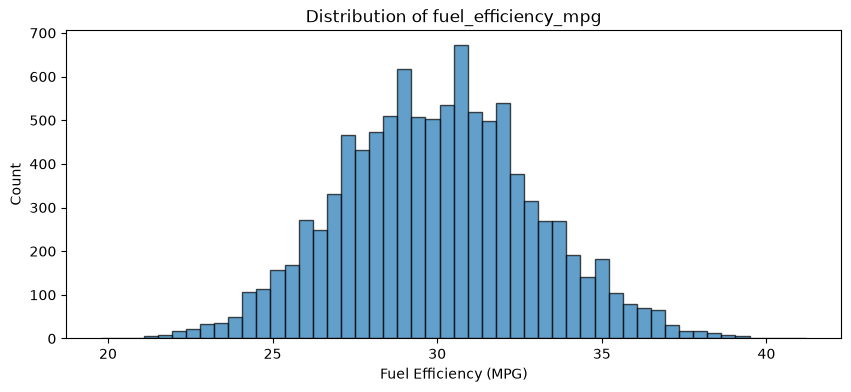

In [4]:
plt.figure(figsize=(10, 4))
plt.hist(df['fuel_efficiency_mpg'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Fuel Efficiency (MPG)')
plt.ylabel('Count')
plt.title('Distribution of fuel_efficiency_mpg')
plt.show()

The distribution is roughly symmetric — no significant long tail.

## Question 1



In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

**Answer Q1:** `horsepower` (877 missing values)

## Question 2



In [6]:
print(f"Median of horsepower: {df['horsepower'].median()}")

Median of horsepower: 254.0


**Answer Q2:** `254`

## Prepare and split the dataset

Define the helper functions from the course:
- `train_linear_regression` — Normal Equation
- `train_linear_regression_reg` — Normal Equation with regularization
- `rmse` — Root Mean Squared Error

Then split the data into train/validation/test (60%/20%/20%).

In [7]:
def train_linear_regression(X, y):
    """Train linear regression using the Normal Equation: w = (X^T X)^-1 X^T y"""
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    """Train linear regression with regularization (Ridge)."""
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    """Root Mean Squared Error."""
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [8]:
# Split with seed 42 (as in the lecture)
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

print(f"Train: {n_train}, Validation: {n_val}, Test: {n_test}")

Train: 6000, Validation: 2000, Test: 2000


## Question 3



In [9]:
# Option 1: Fill with 0
X_train_0 = df_train[features].fillna(0).values
w0_0, w_0 = train_linear_regression(X_train_0, y_train)

X_val_0 = df_val[features].fillna(0).values
y_pred_0 = w0_0 + X_val_0.dot(w_0)

rmse_0 = round(rmse(y_val, y_pred_0), 3)
print(f"RMSE with 0: {rmse_0}")

RMSE with 0: 2.205


In [10]:
# Option 2: Fill with mean (from training only!)
mean_hp = df_train['horsepower'].mean()
print(f"Mean horsepower (training): {mean_hp:.2f}")

X_train_m = df_train[features].fillna(mean_hp).values
w0_m, w_m = train_linear_regression(X_train_m, y_train)

X_val_m = df_val[features].fillna(mean_hp).values
y_pred_m = w0_m + X_val_m.dot(w_m)

rmse_m = round(rmse(y_val, y_pred_m), 3)
print(f"RMSE with mean: {rmse_m}")

Mean horsepower (training): 254.46
RMSE with mean: 2.202


In [11]:
print(f"RMSE with 0:    {rmse_0}")
print(f"RMSE with mean: {rmse_m}")

if rmse_0 < rmse_m:
    print("\nBetter: With 0")
elif rmse_m < rmse_0:
    print("\nBetter: With mean")
else:
    print("\nBetter: Both are equally good")

RMSE with 0:    2.205
RMSE with mean: 2.202

Better: With mean


**Answer Q3:** With mean (RMSE 2.202 vs 2.205)

## Question 4



In [12]:
X_train_0 = df_train[features].fillna(0).values
X_val_0 = df_val[features].fillna(0).values

best_r = None
best_rmse = float('inf')

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0_r, w_r = train_linear_regression_reg(X_train_0, y_train, r=r)
    y_pred_r = w0_r + X_val_0.dot(w_r)
    rmse_r = round(rmse(y_val, y_pred_r), 4)
    print(f"  r={r:>6}: RMSE={rmse_r}")
    if rmse_r < best_rmse:
        best_rmse = rmse_r
        best_r = r

print(f"\nBest r: {best_r} (RMSE={best_rmse})")

  r=     0: RMSE=2.2053
  r=  0.01: RMSE=2.2058
  r=   0.1: RMSE=2.2241
  r=     1: RMSE=2.3492
  r=     5: RMSE=2.4094
  r=    10: RMSE=2.4195
  r=   100: RMSE=2.4292

Best r: 0 (RMSE=2.2053)


**Answer Q4:** `0` (RMSE = 2.2053)

## Question 5



In [13]:
scores = []

for seed in range(10):
    # Split
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_tr = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_vl = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

    y_tr = df_tr['fuel_efficiency_mpg'].values
    y_vl = df_vl['fuel_efficiency_mpg'].values

    # Train (fill with 0, no regularization)
    X_tr = df_tr[features].fillna(0).values
    X_vl = df_vl[features].fillna(0).values

    w0_s, w_s = train_linear_regression(X_tr, y_tr)
    y_pred_s = w0_s + X_vl.dot(w_s)

    sc = rmse(y_vl, y_pred_s)
    scores.append(sc)
    print(f"  seed={seed}: RMSE={round(sc, 4)}")

std_val = round(np.std(scores), 3)
print(f"\nStandard deviation of RMSE scores: {std_val}")

  seed=0: RMSE=2.2392
  seed=1: RMSE=2.2021
  seed=2: RMSE=2.1634
  seed=3: RMSE=2.2044
  seed=4: RMSE=2.2019
  seed=5: RMSE=2.2458
  seed=6: RMSE=2.2697
  seed=7: RMSE=2.1908
  seed=8: RMSE=2.2166
  seed=9: RMSE=2.207

Standard deviation of RMSE scores: 0.029


**Answer Q5:** `0.029`

## Question 6



In [14]:
# Split with seed 9
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_9 = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val_9 = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test_9 = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# Combine train + validation
df_train_full = pd.concat([df_train_9, df_val_9]).reset_index(drop=True)
print(f"Combined train+val size: {len(df_train_full)}")
print(f"Test size: {len(df_test_9)}")

Combined train+val size: 8000
Test size: 2000


In [15]:
# Prepare data
y_train_full = df_train_full['fuel_efficiency_mpg'].values
y_test_9 = df_test_9['fuel_efficiency_mpg'].values

X_train_full = df_train_full[features].fillna(0).values
X_test_9 = df_test_9[features].fillna(0).values

# Train with r=0.001
w0_6, w_6 = train_linear_regression_reg(X_train_full, y_train_full, r=0.001)

# Predict on test
y_pred_6 = w0_6 + X_test_9.dot(w_6)

rmse_6 = round(rmse(y_test_9, y_pred_6), 3)
print(f"RMSE on test: {rmse_6}")

RMSE on test: 2.236


**Answer Q6:** `2.236`

---
